In [1]:
import keypoint_moseq as kpms
import matplotlib.pyplot as plt
import os
from pathlib import Path
import numpy as np



In [2]:
subject = '2209'
session = 'a14'
modelFolder = "labels_v003_0.5scaling"
# modelFolder = "labels_v007"
project_dir = str(Path(f"/Users/ramzyalmulla/research/smearlab/keypoint_moseq_{subject}_{session}/"))
config = lambda: kpms.load_config(project_dir)

base_path_str = "/Volumes/CrucialRZA/smearlab/clickbait-loco/thermister/"
sleap_dir = str(Path(f"{base_path_str}{modelFolder}/"))

# sleap_file = str(list(Path(sleap_dir).glob(f"**/*{subject}_{session}.slp"))[0])  # any .slp or .h5 file with predictions for a single video
sleap_file = str(list(Path(sleap_dir).glob(f"**/[0-9]*{subject}_{session}.slp"))[0])  # any .slp or .h5 file with predictions for a single video

video_dir = str(Path(base_path_str+f"*/{session.strip('_raw')}/"))  # any directory containing videos (e.g. .mp4, .avi) and/or sleap files with predictions for those videos
if not os.path.exists(project_dir):
    kpms.setup_project(project_dir, sleap_file=sleap_file,video_dir=video_dir) 

In [3]:
# load data 
keypoint_data_path = [str(i) for i in list(Path(sleap_dir).glob(f"**/[0-9]*{session}.slp"))]  # can be a file, a directory, or a list of files
coordinates, confidences, bodyparts = kpms.load_keypoints(keypoint_data_path, "sleap")

Loading keypoints: 100%|██████████████████| 3/3 [00:04<00:00,  1.49s/it]


In [4]:

kpms.update_config(project_dir,
                   use_bodyparts=['nose1','neck1','forepawL1','forepawR1','centroid1','hindpawL1','hindpawR1','tailstart1'],
                   anterior_bodyparts=["nose1","neck1"],posterior_bodyparts=["tailstart1"], num_states=100,
                   fps=30)

In [5]:

coordinates, confidences = kpms.outlier_removal(
    coordinates,
    confidences,
    project_dir,
    overwrite=False,
    **config()
)


In [6]:
# cind = bodyparts.index('centroid1')
# seshkey = list(coordinates.keys())[0]
# coordinates[seshkey] = coordinates[seshkey] - coordinates[seshkey][:,cind:cind+1,:]

In [7]:
data, metadata = kpms.format_data(coordinates, confidences, **config())

In [8]:
# %matplotlib widget
# kpms.noise_calibration(project_dir, coordinates, confidences, **config())


>=90.0% of variance exlained by 8 components.


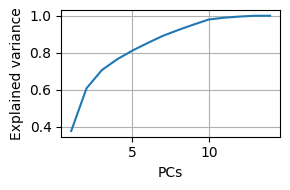

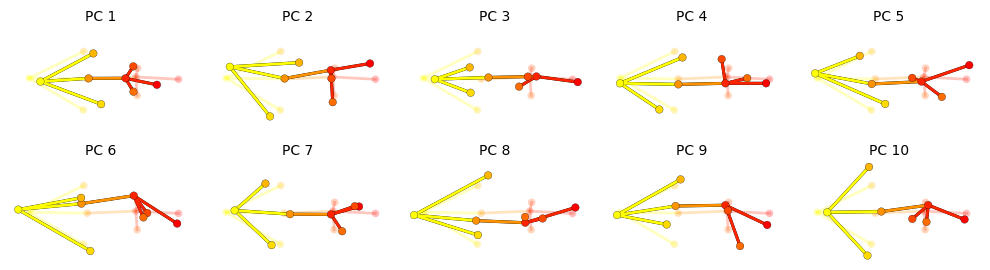

In [9]:
plt.close("all")
%matplotlib inline
pca = kpms.fit_pca(**data, **config())
kpms.save_pca(pca, project_dir)

kpms.print_dims_to_explain_variance(pca, 0.9)
kpms.plot_scree(pca, project_dir=project_dir)
kpms.plot_pcs(pca, project_dir=project_dir, **config())

# use the following to load an already fit model
# pca = kpms.load_pca(project_dir)

In [10]:
kpms.update_config(project_dir, latent_dim=8)

In [11]:
kpms.update_config(
    project_dir,
    sigmasq_loc=kpms.estimate_sigmasq_loc(data["Y"], data["mask"], filter_size=config()["fps"])
)

In [12]:
import jax_moseq
data = jax_moseq.utils.debugging.convert_data_precision(data)


In [13]:
# initialize the model
model = kpms.init_model(data, pca=pca, **config())

# # optionally modify kappa
model = kpms.update_hypparams(model, kappa=1e12)

In [14]:
# num_ar_iters = 50

# model, model_name = kpms.fit_model(
#     model, data, metadata, project_dir, jitter=1e-1,ar_only=True, num_iters=num_ar_iters
# )

In [15]:
# from jax_moseq.models.keypoint_slds.decision_list import greedy_decision_list_permutation, permute_model_states

# # 1. AR-HMM Warmup Phase (Fits discrete/AR parameters to rigid PCA)
# num_ar_iters = 50
# model, model_name = kpms.fit_model(
#     model, data, metadata, project_dir, jitter=1e-1, ar_only=True, slds_only=False, num_iters=num_ar_iters
# )




In [25]:
from jax_moseq.models.keypoint_slds.decision_list import greedy_decision_list_permutation, permute_model_states
num_ar_iters = 50
model_name = "2026_05_26-11_30_35"
# load the most recent model checkpoint
model, data, metadata, current_iter = kpms.load_checkpoint(project_dir, model_name, iteration=num_ar_iters)

In [26]:
# 2. Extract optimal ordering and permute model based on settled SLDS latents
num_states = model["hypparams"]["trans_hypparams"]["num_states"]
optimal_permutation = greedy_decision_list_permutation(
    model["states"]["x"], 
    model["states"]["z"], 
    num_states
)
model = permute_model_states(model, optimal_permutation)

Fitting greedy decision list for stick-breaking...
Optimal stick-breaking permutation: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]


In [ ]:
# from importlib import reload
# reload(jax_moseq)

NameError: name 'jax_moseq' is not defined

Outputs will be saved to /Users/ramzyalmulla/research/smearlab/keypoin
t_moseq_2209_a14/2026_05_26-12_01_57


  5%|█▌                              | 25/501 [04:48<1:33:02, 11.73s/it]

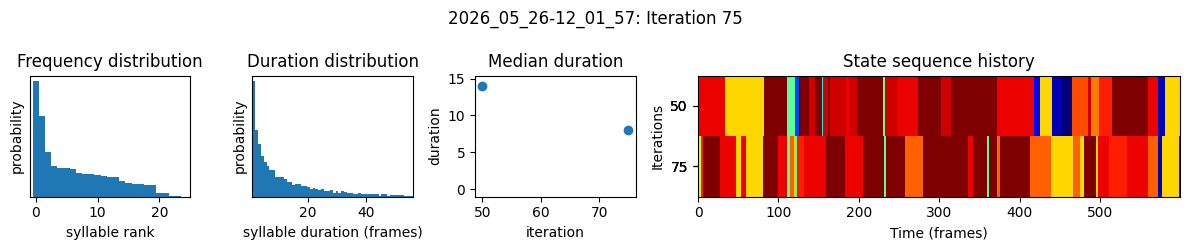

 10%|███▏                            | 50/501 [09:47<1:29:34, 11.92s/it]

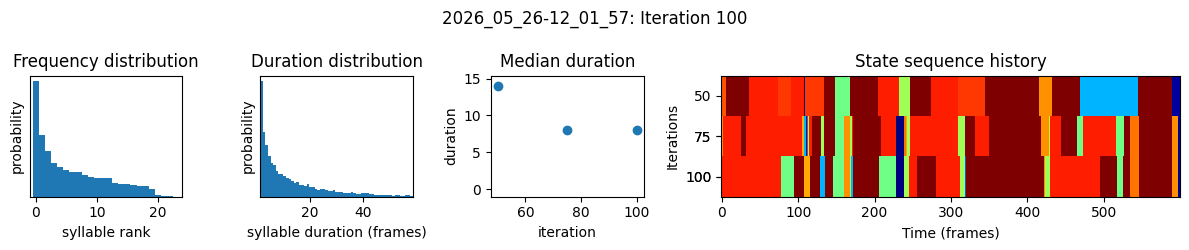

 15%|████▊                           | 75/501 [14:38<1:19:35, 11.21s/it]

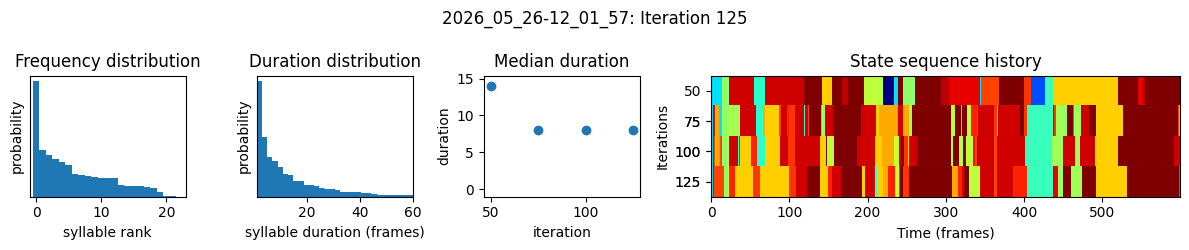

 20%|██████▏                        | 100/501 [19:16<1:14:49, 11.20s/it]

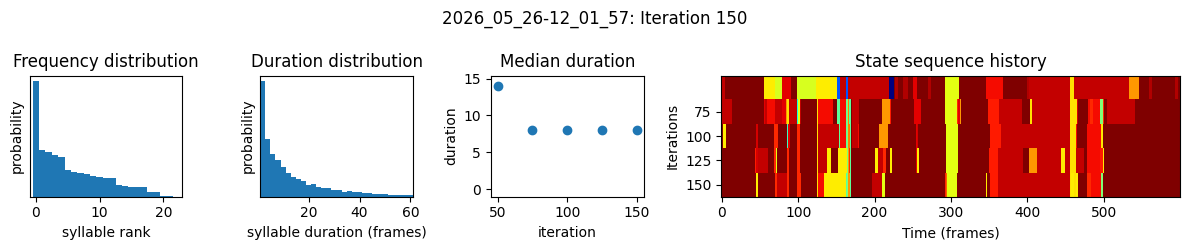

 25%|███████▋                       | 125/501 [23:55<1:09:29, 11.09s/it]

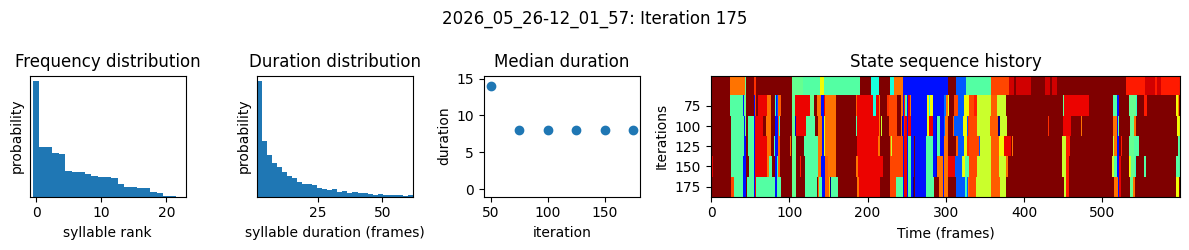

 30%|█████████▎                     | 150/501 [28:32<1:04:54, 11.10s/it]

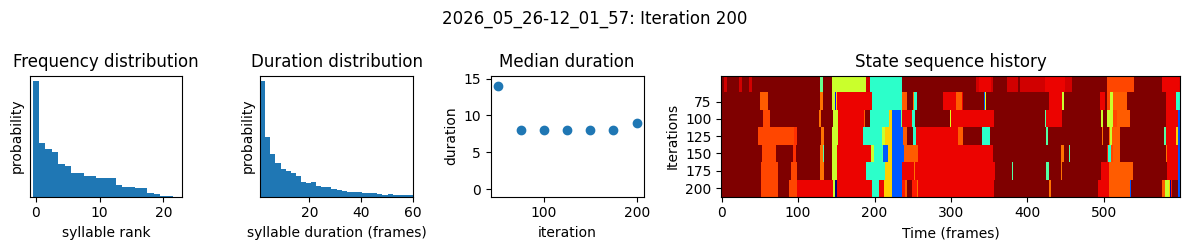

 35%|██████████▊                    | 175/501 [33:12<1:00:51, 11.20s/it]

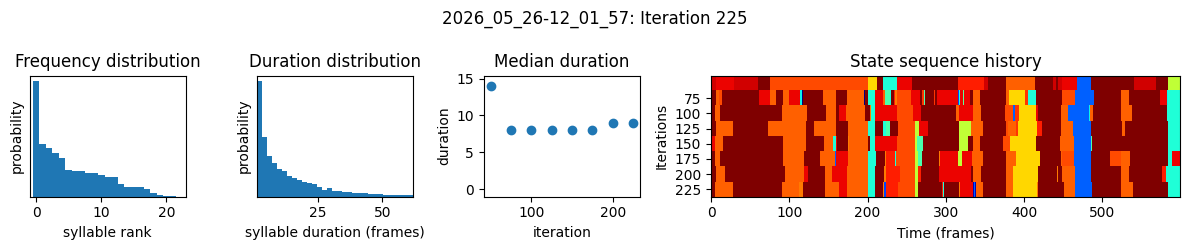

 40%|█████████████▏                   | 200/501 [37:51<55:18, 11.03s/it]

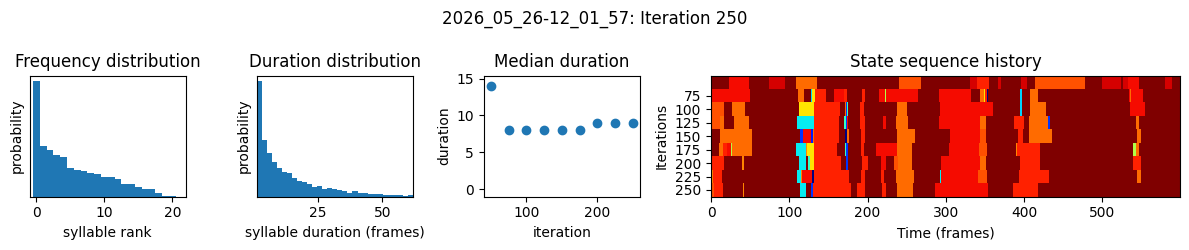

 45%|██████████████▊                  | 225/501 [42:42<55:07, 11.98s/it]

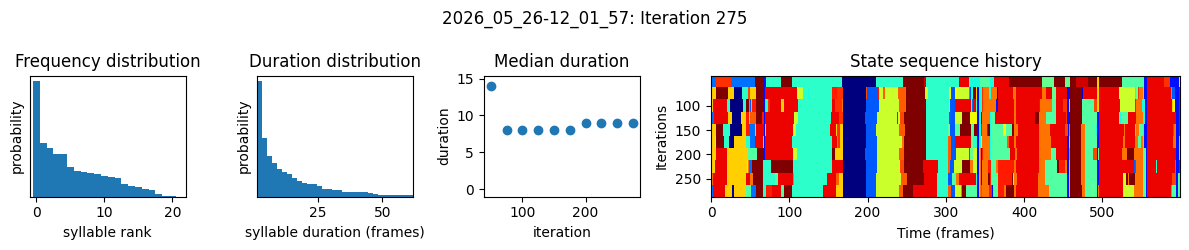

 50%|████████████████▍                | 250/501 [47:46<48:13, 11.53s/it]

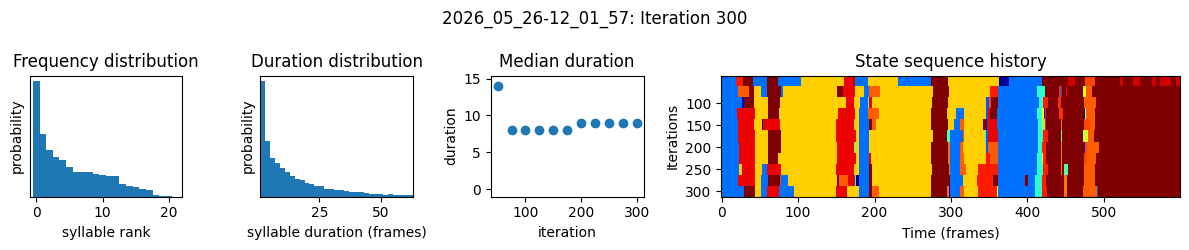

 55%|██████████████████               | 275/501 [52:29<42:44, 11.35s/it]

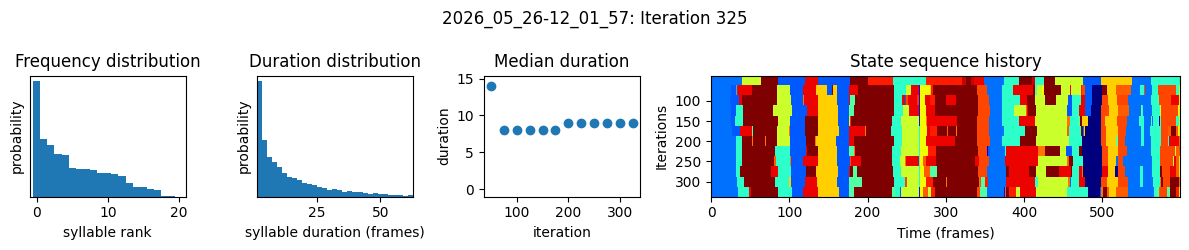

 60%|███████████████████▊             | 300/501 [57:18<40:55, 12.21s/it]

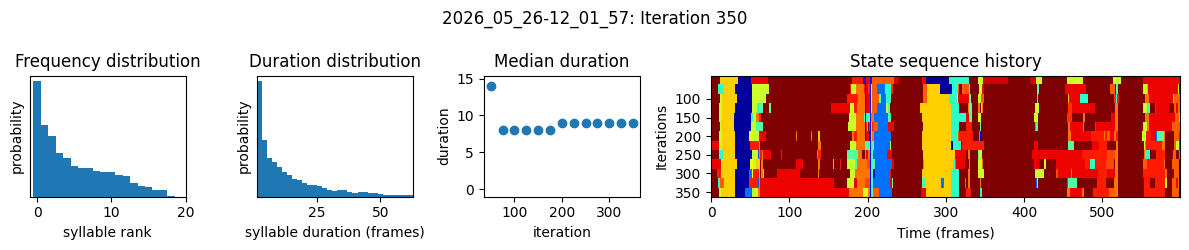

 65%|████████████████████           | 325/501 [1:02:10<32:52, 11.21s/it]

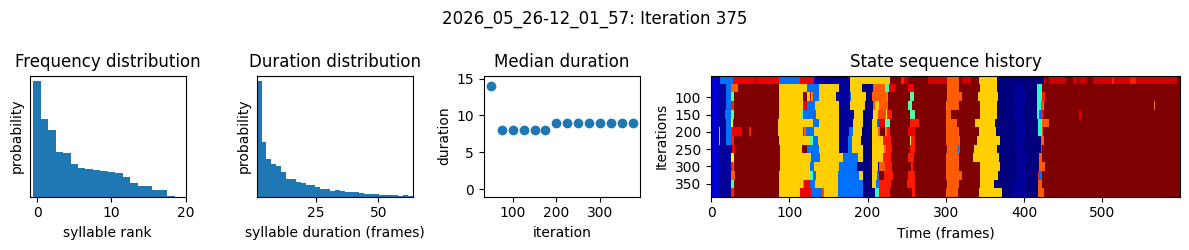

 70%|█████████████████████▋         | 350/501 [1:06:52<28:26, 11.30s/it]

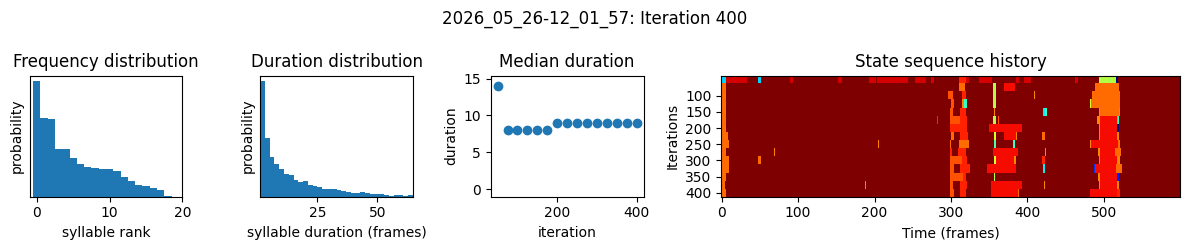

 75%|███████████████████████▏       | 375/501 [1:11:34<24:01, 11.44s/it]

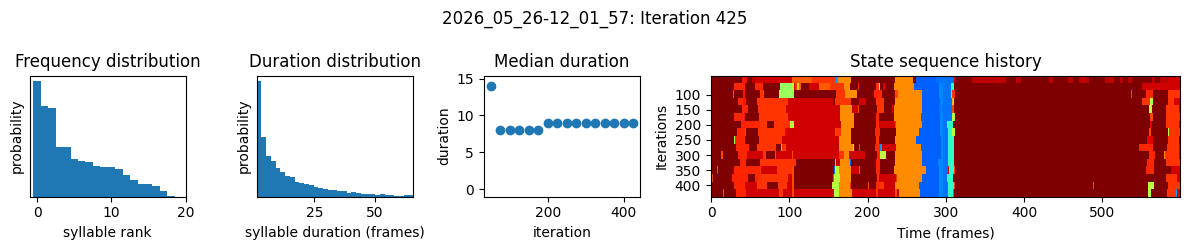

 80%|████████████████████████▊      | 400/501 [1:16:23<19:17, 11.46s/it]

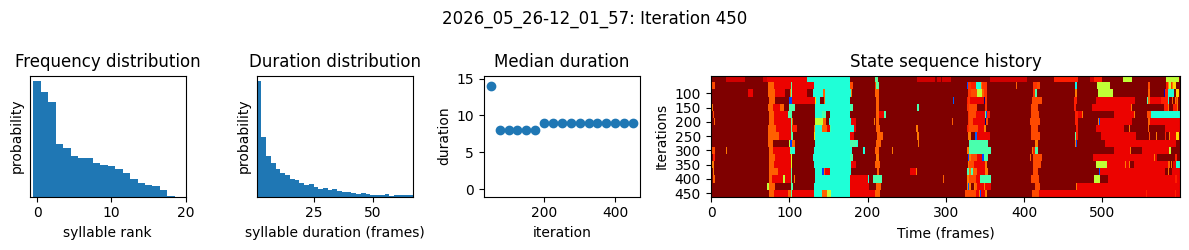

 85%|██████████████████████████▎    | 425/501 [1:21:19<15:04, 11.90s/it]

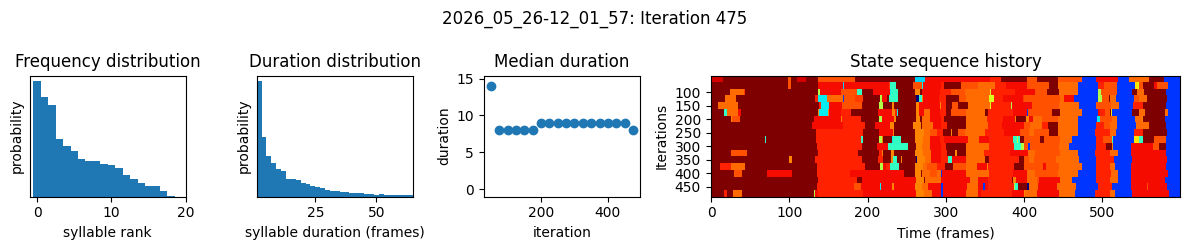

 90%|███████████████████████████▊   | 450/501 [1:26:09<09:40, 11.38s/it]

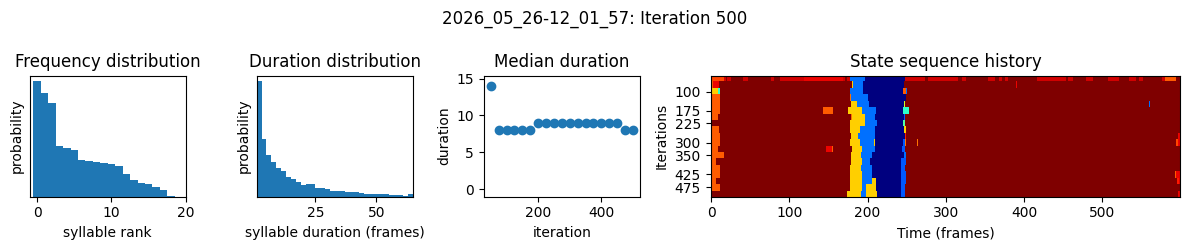

 95%|█████████████████████████████▍ | 475/501 [1:31:00<05:18, 12.26s/it]

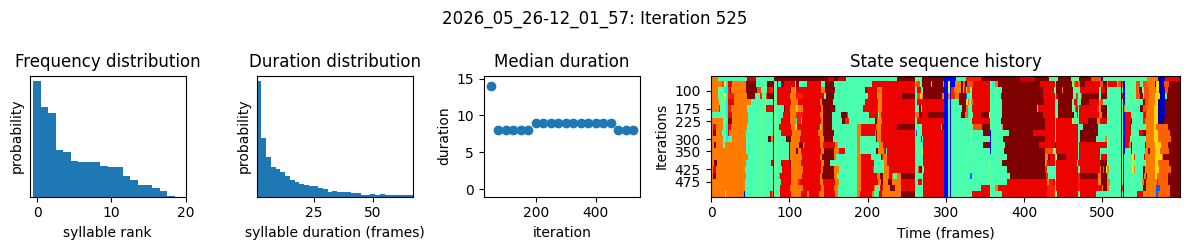

100%|██████████████████████████████▉| 500/501 [1:35:49<00:11, 11.64s/it]

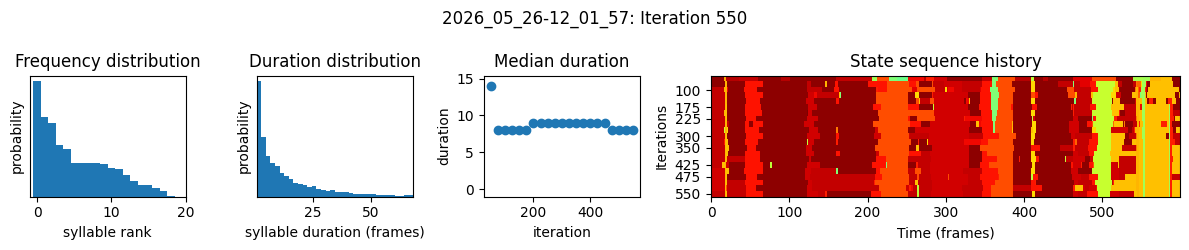

100%|███████████████████████████████| 501/501 [1:36:01<00:00, 11.50s/it]


In [27]:
# model = kpms.update_hypparams(model, kappa=5e3)
# 3. rSLDS Fitting Phase
model, model_name = kpms.fit_model(
    model, data, metadata, project_dir, jitter=1e-3, ar_only=False, start_iter=num_ar_iters, num_iters=num_ar_iters+500
)

In [35]:

model_name = '2026_05_26-12_01_57'

In [39]:
# load the most recent model checkpoint
model, data, metadata, current_iter = kpms.load_checkpoint(project_dir, model_name)

# modify a saved checkpoint so syllables are ordered by frequency
kpms.reindex_syllables_in_checkpoint(project_dir, model_name);

# extract results
results = kpms.extract_results(model, metadata, project_dir, model_name)

Reindexing: 100%|███████████| 21/21 [00:01<00:00, 18.52model snapshot/s]

Saved results to /Users/ramzyalmulla/research/smearlab/keypoint_moseq_
2209_a14/2026_05_26-12_01_57/results.h5


Saving trajectory plots to /Users/ramzyalmulla/research/smearlab/keypoint_moseq_2209_a14/2026_05_26-12_01_57/trajectory_plots


Generating trajectory plots: 100%|██████| 16/16 [00:02<00:00,  5.50it/s]


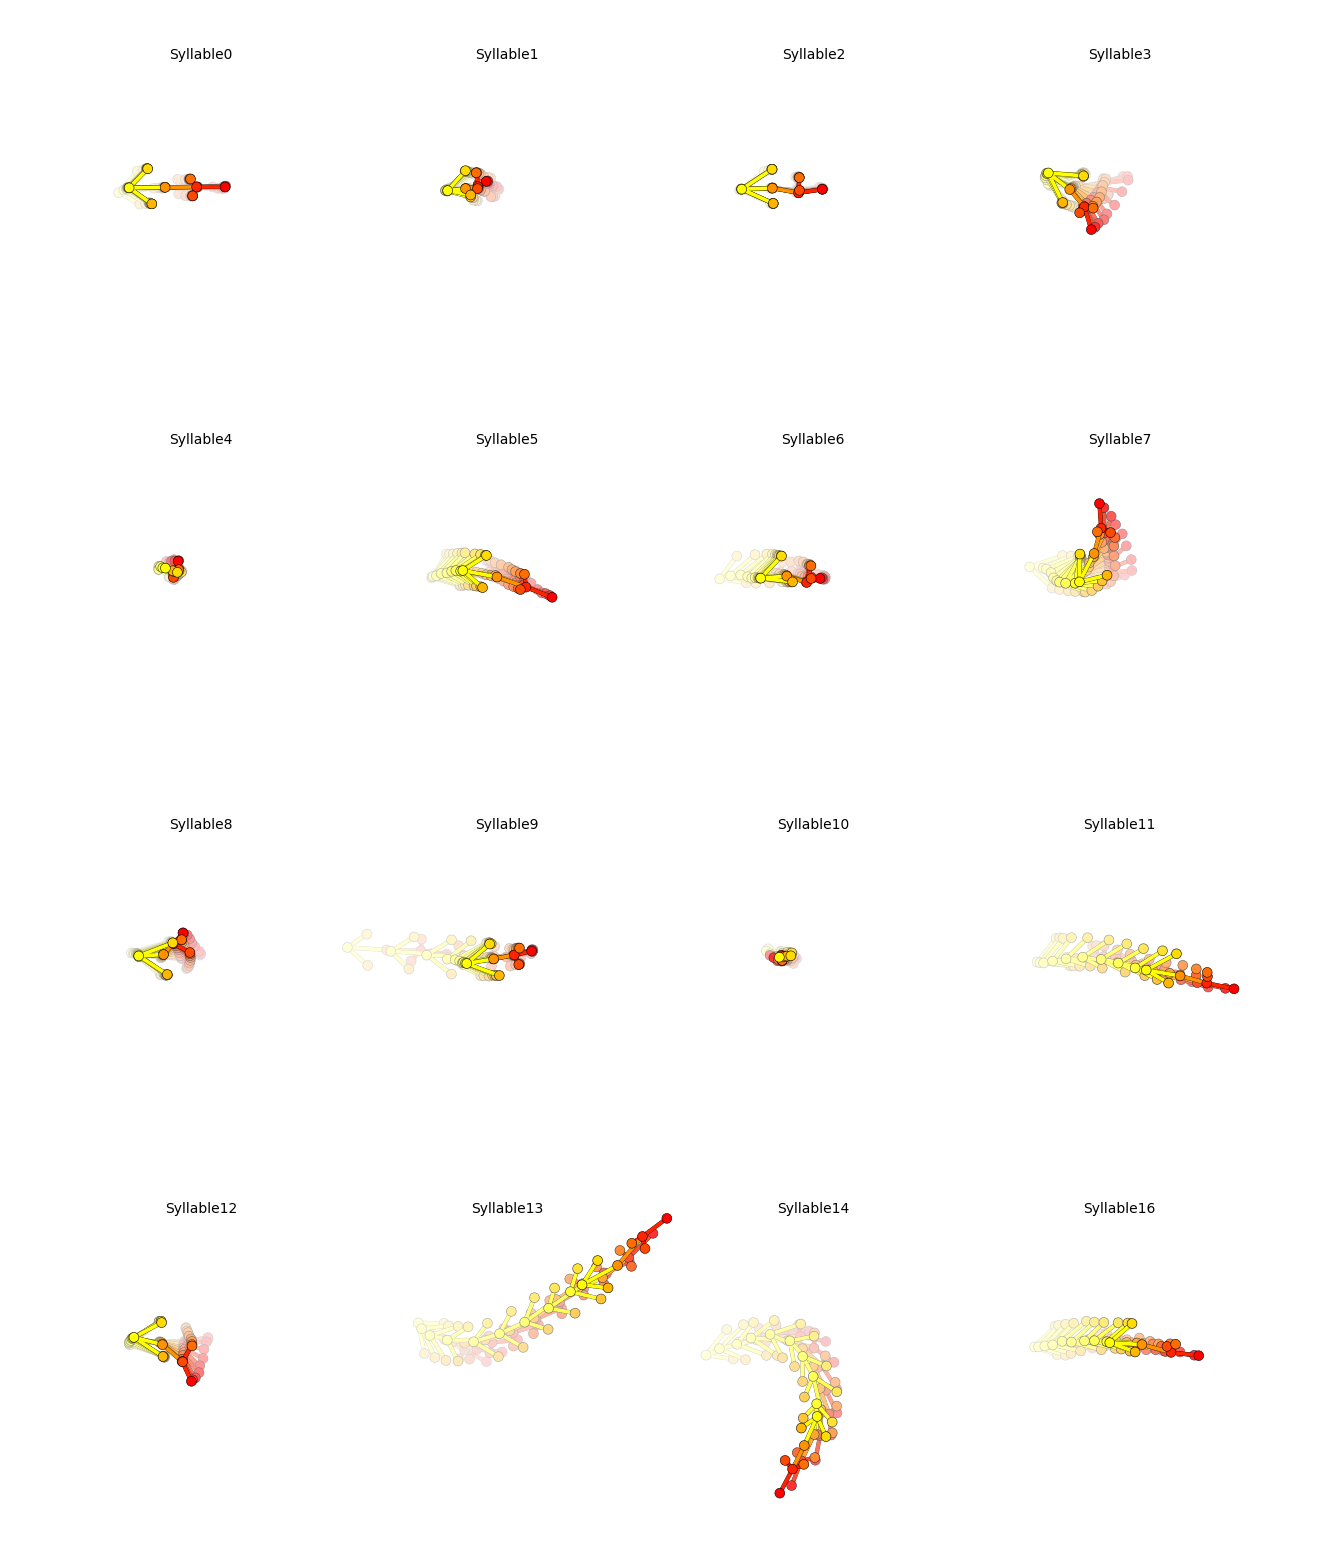

In [40]:
# results = kpms.load_results(project_dir, model_name)
kpms.generate_trajectory_plots(coordinates, results, 
                               project_dir, model_name, 
                               **config())


Saving dendrogram plot to /Users/ramzyalmulla/research/smearlab/keypoint_moseq_2209_a14/2026_05_26-12_01_57/similarity_dendrogram


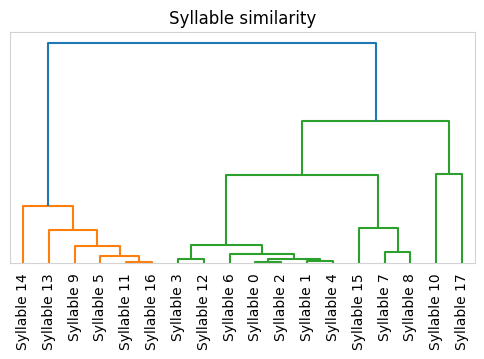

In [41]:
kpms.plot_similarity_dendrogram(coordinates, results, project_dir, model_name,**config())

In [42]:
video_dir = str(Path(base_path_str))  # any directory containing videos (e.g. .mp4, .avi) and/or sleap files with predictions for those videos
kpms.update_config(project_dir,video_dir=video_dir)

In [43]:
kpms.save_results_as_csv(results,project_dir,model_name)

Saving to csv: 100%|██████████████████████| 3/3 [00:00<00:00,  5.80it/s]


In [45]:

kpms.generate_grid_movies(results, project_dir, model_name, 
                          coordinates=coordinates, overlay_keypoints=True, **config());

Writing grid movies to /Users/ramzyalmulla/research/smearlab/keypoint_moseq_2209_a14/2026_05_26-12_01_57/grid_movies



Videos will be downscaled by a factor of 0.65 so that the grid movies
are under 1920 pixels. Use `max_video_size` to increase or decrease
this size limit.



Using window size of 496 pixels


Generating grid movies: 100%|███████████| 18/18 [02:55<00:00,  9.74s/it]os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.


In [ ]:
modelSubject = '2209'
modelSession = 'a14'
subject = '2209'
session = 'a17'
outDir = os.path.join(project_dir,model_name,f'{subject}_{session}')
modelFolder = "labels_v003_0.5scaling"
# project_dir = str(Path(f"/Users/ramzyalmulla/research/smearlab/keypoint_moseq_{modelSubject}_{modelSession}/"))
project_dir = "/Users/ramzyalmulla/research/smearlab/keypoint_moseq_2209_a14"
model_name = "2026_05_25-17_32_36"
config = lambda: kpms.load_config(project_dir)

In [ ]:
sleap_dir

'/Volumes/CrucialRZA/smearlab/clickbait-loco/thermister/labels_v003_0.5scaling'

In [ ]:
# load the most recent model checkpoint and pca object
model = kpms.load_checkpoint(project_dir, model_name)[0]

# load new data (e.g. from deeplabcut)
new_data = str(list(Path(sleap_dir).glob(f"**/*{subject}*_{session}.slp"))[0])  # can be a file, a directory, or a list of files
coordinates, confidences, bodyparts = kpms.load_keypoints(new_data, "sleap")
coordinates, confidences = kpms.outlier_removal(
    coordinates,
    confidences,
    project_dir,
    overwrite=False,
    **config()
)


Loading keypoints: 100%|██████████████████| 1/1 [00:02<00:00,  2.57s/it]


In [ ]:
data, metadata = kpms.format_data(coordinates, confidences, **config())
import jax_moseq
data = jax_moseq.utils.debugging.convert_data_precision(data)


# apply saved model to new data
results = kpms.apply_model(model, data, metadata, project_dir, model_name, 
                           results_path=outDir, overwrite=True,**config())

# if applying to data that includes the original training recordings,
# set overwrite=True to replace the existing results for those recordings
# results = kpms.apply_model(model, data, metadata, project_dir, model_name, overwrite=True, **config())

# optionally rerun `save_results_as_csv` to export the new results
# kpms.save_results_as_csv(results, project_dir, model_name)

Applying model: 100%|█████████████████| 500/500 [54:07<00:00,  6.49s/it]

Saved results to /Users/ramzyalmulla/research/smearlab/keypoint_moseq_
2209_a14/2026_05_25-17_32_36/2209_a17


In [ ]:
# optionally rerun `save_results_as_csv` to export the new results
outDir = os.path.join(project_dir,model_name,f'{subject}')
if not os.path.exists(outDir):
    os.mkdir(outDir)

kpms.save_results_as_csv(results, project_dir, model_name, save_dir=outDir)

Saving to csv: 100%|██████████████████████| 1/1 [00:00<00:00,  3.89it/s]


Saving trajectory plots to /Users/ramzyalmulla/research/smearlab/keypoint_moseq_2209_a14/2026_05_25-17_32_36/2209


Generating trajectory plots: 100%|██████| 12/12 [00:02<00:00,  4.84it/s]


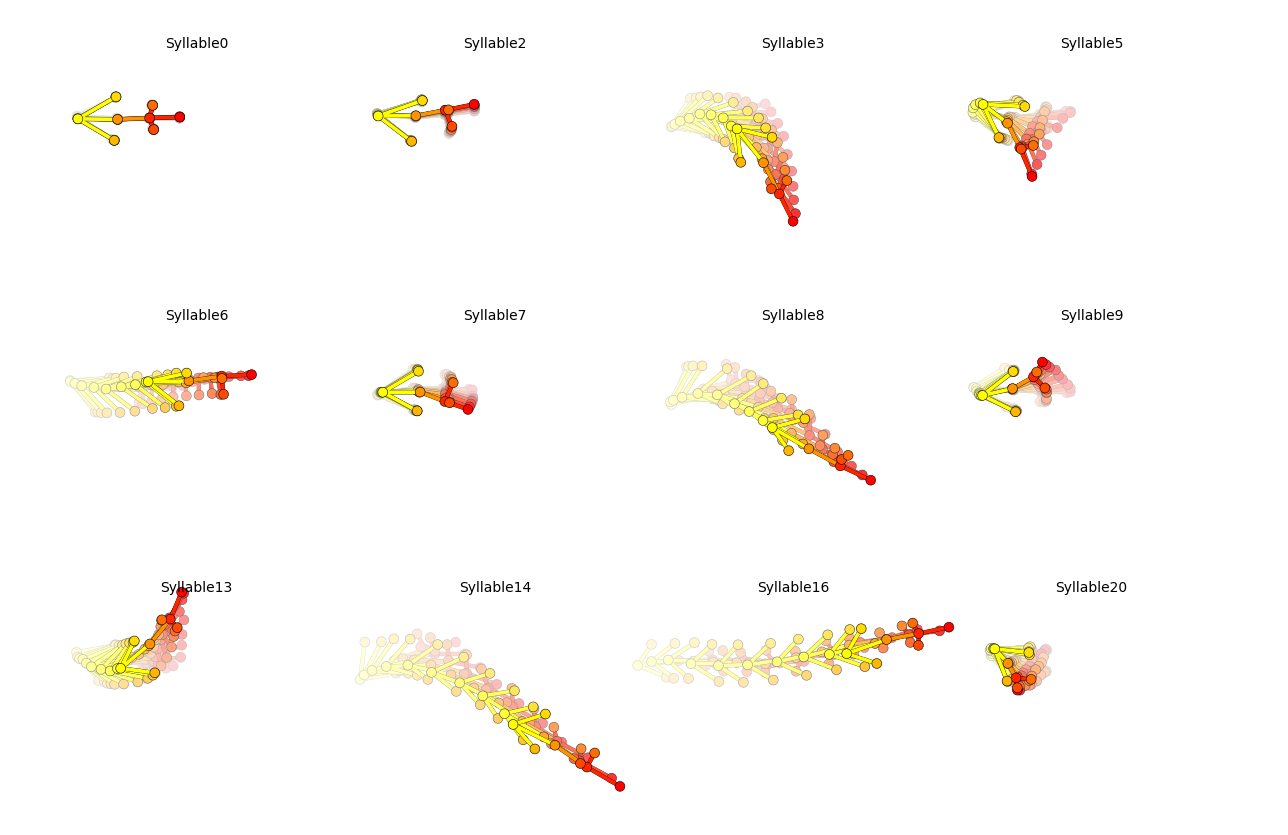

In [ ]:
kpms.generate_trajectory_plots(coordinates, results, 
                               project_dir, model_name, output_dir=outDir,
                               **config())

In [ ]:

kpms.generate_grid_movies(results, project_dir, model_name, outDir,
                          coordinates=coordinates, overlay_keypoints=True, **config());